# DS/AI: Data Science Group Assignment - Great Cormorant

**Group name:** minecraft

**Student names & numbers:**
* Gabriel Chitarliev - 98920
* Aleksandar Manev - 99052
* Alexander Atanasov - 101953
* Dimitar Yosifov - 00099118

---

## Setup

**Import libraries**

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as colors
import contextily as cx
import numpy as np

**Load dataset**

In [50]:
df_sightings = pd.read_csv('./Phalacrocorax carbo.csv',sep=',', low_memory=False, parse_dates=["eventDate"])
df_habitats = pd.read_csv('./habitats_cbs_2022.csv', sep=',', low_memory=False)

knmi = pd.read_csv(
    "KNMI.txt",
    comment="#",
    names=["STN", "YYYYMMDD", "FG", "TG", "TN", "TX", "SQ", "Q", "RH", "UG"],
    skipinitialspace=True,
)

df = df_sightings.merge(
    df_habitats,
    on=["decimalLatitude", "decimalLongitude"],
    how="inner",
)

In [51]:
df.info() # Before merge with KNMI - 15 columns

<class 'pandas.DataFrame'>
RangeIndex: 12558756 entries, 0 to 12558755
Data columns (total 15 columns):
 #   Column                     Dtype         
---  ------                     -----         
 0   decimalLatitude            float64       
 1   decimalLongitude           float64       
 2   eventDate                  datetime64[us]
 3   total_observations         float64       
 4   speciesgroup_observations  int64         
 5   Phalacrocorax carbo        str           
 6   agricultural               float64       
 7   built                      float64       
 8   coast                      float64       
 9   forest                     float64       
 10  other                      float64       
 11  sand/heather               float64       
 12  water                      float64       
 13  wetland                    float64       
 14  main_habitat               str           
dtypes: datetime64[us](1), float64(11), int64(1), str(2)
memory usage: 1.5 GB


In [52]:
df["month"] = df["eventDate"].dt.month

In [53]:
knmi["date"] = pd.to_datetime(knmi["YYYYMMDD"], format="%Y%m%d")

knmi["RH"] = knmi["RH"].replace(-1, 0)
knmi["SQ"] = knmi["SQ"].replace(-1, 0)

for col in ["TG", "TN", "TX", "FG", "RH", "SQ"]:
    knmi[col] = knmi[col] / 10

knmi.head(5)

,STN,YYYYMMDD,FG,TG,TN,TX,SQ,Q,RH,UG,date
0,240,20100101,4.6,-1.6,-6.3,0.8,5.0,343.0,0.0,82.0,2010-01-01
1,240,20100102,4.3,-0.6,-5.5,1.6,0.3,146.0,0.7,95.0,2010-01-02
2,240,20100103,2.8,-3.4,-7.5,-0.5,5.2,360.0,0.0,91.0,2010-01-03
3,240,20100104,4.1,-1.5,-5.1,1.2,1.4,201.0,0.3,97.0,2010-01-04
4,240,20100105,3.9,-0.2,-2.2,2.0,0.8,195.0,0.4,95.0,2010-01-05


In [54]:
# df = df_sightings.merge(
#     df_habitats,
#     on=["decimalLatitude", "decimalLongitude"],
#     how="inner",
# )

STATIONS = {
    240: (52.318, 4.790),   # Schiphol
    260: (52.100, 5.180),   # De Bilt
    270: (53.224, 5.752),   # Leeuwarden
    280: (53.125, 6.585),   # Eelde
    290: (52.274, 6.891),   # Twenthe
    310: (51.442, 3.596),   # Vlissingen
    330: (51.992, 4.122),   # Hoek van Holland
    344: (51.962, 4.447),   # Rotterdam
    380: (50.906, 5.762),   # Maastricht
    391: (51.498, 6.197),   # Arcen
}

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dp = np.radians(lat2 - lat1)
    dl = np.radians(lon2 - lon1)
    a = np.sin(dp/2)**2 + np.cos(p1) * np.cos(p2) * np.sin(dl/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

cells = df[["decimalLatitude", "decimalLongitude"]].drop_duplicates().reset_index(drop=True)

stn_ids  = np.array(list(STATIONS.keys()))
stn_lats = np.array([s[0] for s in STATIONS.values()])
stn_lons = np.array([s[1] for s in STATIONS.values()])

dist = haversine_km(
    cells["decimalLatitude"].values[:, None],
    cells["decimalLongitude"].values[:, None],
    stn_lats[None, :],
    stn_lons[None, :],
)
cells["STN"] = stn_ids[dist.argmin(axis=1)]

print("Grid cells per station:")
print(cells["STN"].value_counts().sort_index())
cells.head()
leftover = ["STN", "STN_x", "STN_y", "TG", "TN", "TX", "RH", "FG", "UG", "SQ", "Q", "date"]

df = df.drop(columns=[c for c in leftover if c in df.columns])

df = df.merge(cells, on=["decimalLatitude", "decimalLongitude"], how="left")

df = df.merge(
    knmi[["STN", "date", "TG", "TN", "TX", "RH", "FG", "UG", "SQ", "Q"]],
    left_on=["STN", "eventDate"],
    right_on=["STN", "date"],
    how="left",
).drop(columns=["date"])

Grid cells per station:
STN
240    198
260    345
270    286
280    306
290    266
310    160
330     59
344    202
380    120
391    207
Name: count, dtype: int64


In [55]:
df.info() # After the merge with KNMI - 25 columns

<class 'pandas.DataFrame'>
RangeIndex: 12558756 entries, 0 to 12558755
Data columns (total 25 columns):
 #   Column                     Dtype         
---  ------                     -----         
 0   decimalLatitude            float64       
 1   decimalLongitude           float64       
 2   eventDate                  datetime64[us]
 3   total_observations         float64       
 4   speciesgroup_observations  int64         
 5   Phalacrocorax carbo        str           
 6   agricultural               float64       
 7   built                      float64       
 8   coast                      float64       
 9   forest                     float64       
 10  other                      float64       
 11  sand/heather               float64       
 12  water                      float64       
 13  wetland                    float64       
 14  main_habitat               str           
 15  month                      int32         
 16  STN                        int64         
 17

In [56]:
df.to_parquet("cormorant_habitat_weather.parquet", index=False)

---

## 1. Business Understanding



**Business objective(s)**

- Balancing the conservation of the Great Cormorant with the economic viability of the Dutch inland fisheries and aquaculture sectors. The primary goal is to provide a data-driven framework that minimizes 'serious damage' to fish stocks and commercial yields through targeted management strategies and predictive impact modeling.


**Business success criteria**



**Data mining goal(s)**

- Use Latitude/Longitude data to identify "hotspots" where high cormorant density overlaps with high-value fishing/aquaculture zones

- Build a model to correlate cormorant sightings with actual fish stock depletion or wounding rates.

**Data mining success criteria**

- The model identifies high-impact zones with a Precision of >50%, ensuring that management resources are not wasted on low-impact areas.

## 2. Data Understanding


In [57]:
print("Shape:", knmi.shape)
knmi.head(11)

Shape: (59589, 11)


,STN,YYYYMMDD,FG,TG,TN,TX,SQ,Q,RH,UG,date
0,240,20100101,4.6,-1.6,-6.3,0.8,5.0,343.0,0.0,82.0,2010-01-01
1,240,20100102,4.3,-0.6,-5.5,1.6,0.3,146.0,0.7,95.0,2010-01-02
2,240,20100103,2.8,-3.4,-7.5,-0.5,5.2,360.0,0.0,91.0,2010-01-03
3,240,20100104,4.1,-1.5,-5.1,1.2,1.4,201.0,0.3,97.0,2010-01-04
4,240,20100105,3.9,-0.2,-2.2,2.0,0.8,195.0,0.4,95.0,2010-01-05
5,240,20100106,3.4,-2.8,-6.6,0.3,5.5,449.0,2.8,95.0,2010-01-06
6,240,20100107,2.7,-4.8,-11.5,-2.4,4.7,376.0,0.0,94.0,2010-01-07
7,240,20100108,4.0,-5.7,-13.8,-2.2,2.1,246.0,0.0,95.0,2010-01-08
8,240,20100109,10.0,-1.8,-4.5,-0.4,0.0,198.0,0.6,88.0,2010-01-09
9,240,20100110,7.0,-0.1,-0.6,0.4,0.0,80.0,1.7,95.0,2010-01-10


In [58]:
df.head(3)

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Phalacrocorax carbo,agricultural,built,coast,forest,...,month,STN,TG,TN,TX,RH,FG,UG,SQ,Q
0,50.75,5.65,2010-01-01,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,1,380,-2.0,-6.1,-1.1,0.1,4.6,91.0,0.0,33.0
1,50.75,5.65,2010-01-02,25.0,25,1,1.7747,0.0568,0.0,0.0616,...,1,380,-2.1,-6.7,0.2,0.2,4.9,90.0,2.7,260.0
2,50.75,5.65,2010-01-03,3.0,3,0,1.7747,0.0568,0.0,0.0616,...,1,380,-3.9,-6.7,0.8,3.0,3.3,92.0,0.3,178.0


In [59]:
print("Shape:", df.shape)
df.head(3)

Shape: (12558756, 25)


,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Phalacrocorax carbo,agricultural,built,coast,forest,...,month,STN,TG,TN,TX,RH,FG,UG,SQ,Q
0,50.75,5.65,2010-01-01,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,1,380,-2.0,-6.1,-1.1,0.1,4.6,91.0,0.0,33.0
1,50.75,5.65,2010-01-02,25.0,25,1,1.7747,0.0568,0.0,0.0616,...,1,380,-2.1,-6.7,0.2,0.2,4.9,90.0,2.7,260.0
2,50.75,5.65,2010-01-03,3.0,3,0,1.7747,0.0568,0.0,0.0616,...,1,380,-3.9,-6.7,0.8,3.0,3.3,92.0,0.3,178.0


In [60]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12558756 entries, 0 to 12558755
Data columns (total 25 columns):
 #   Column                     Dtype         
---  ------                     -----         
 0   decimalLatitude            float64       
 1   decimalLongitude           float64       
 2   eventDate                  datetime64[us]
 3   total_observations         float64       
 4   speciesgroup_observations  int64         
 5   Phalacrocorax carbo        str           
 6   agricultural               float64       
 7   built                      float64       
 8   coast                      float64       
 9   forest                     float64       
 10  other                      float64       
 11  sand/heather               float64       
 12  water                      float64       
 13  wetland                    float64       
 14  main_habitat               str           
 15  month                      int32         
 16  STN                        int64         
 17

In [61]:
print(df_sightings["Phalacrocorax carbo"].unique())

<ArrowStringArray>
[      '0',       '1',       '2',       '4',       '3',       '5',       '6',
       '7',      '10',      '11',      '20',       '9',       '8',      '15',
      '17',      '16',      '12',      '14',      '24',      '22',      '25',
      '21',      '27',      '18',      '50',      '13',      '28',      '26',
      '35',      '23',      '19',      '43',      '56',      '36',      '30',
      '41',      '62',      '32',      '37',      '34',      '31',      '51',
      '67',      '29',      '42',      '55',     '109',      '45',      '57',
      '58',      '38',      '33',      '63',      '-1', 'unknown']
Length: 55, dtype: str


In [62]:
# df.to_csv('bird_and_habitats.csv', index=False)

In [63]:
df['eventDate'] = pd.to_datetime(df['eventDate'], errors='coerce')
cols = [
    "total_observations",
    "speciesgroup_observations",
    "Phalacrocorax carbo"
]

df[cols] = df[cols].apply(pd.to_numeric, errors="coerce").fillna(0)

In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12558756 entries, 0 to 12558755
Data columns (total 25 columns):
 #   Column                     Dtype         
---  ------                     -----         
 0   decimalLatitude            float64       
 1   decimalLongitude           float64       
 2   eventDate                  datetime64[us]
 3   total_observations         float64       
 4   speciesgroup_observations  int64         
 5   Phalacrocorax carbo        int64         
 6   agricultural               float64       
 7   built                      float64       
 8   coast                      float64       
 9   forest                     float64       
 10  other                      float64       
 11  sand/heather               float64       
 12  water                      float64       
 13  wetland                    float64       
 14  main_habitat               str           
 15  month                      int32         
 16  STN                        int64         
 17

In [65]:
df['year'] = df['eventDate'].dt.year
df['month'] = df['eventDate'].dt.month
df['week'] = df['eventDate'].dt.isocalendar().week

In [66]:
df.head(5)

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Phalacrocorax carbo,agricultural,built,coast,forest,...,TG,TN,TX,RH,FG,UG,SQ,Q,year,week
0,50.75,5.65,2010-01-01,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,-2.0,-6.1,-1.1,0.1,4.6,91.0,0.0,33.0,2010,53
1,50.75,5.65,2010-01-02,25.0,25,1,1.7747,0.0568,0.0,0.0616,...,-2.1,-6.7,0.2,0.2,4.9,90.0,2.7,260.0,2010,53
2,50.75,5.65,2010-01-03,3.0,3,0,1.7747,0.0568,0.0,0.0616,...,-3.9,-6.7,0.8,3.0,3.3,92.0,0.3,178.0,2010,53
3,50.75,5.65,2010-01-04,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,-5.4,-10.5,-3.0,0.4,3.3,89.0,0.4,218.0,2010,1
4,50.75,5.65,2010-01-05,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,-2.3,-4.6,-1.0,0.4,3.5,92.0,0.0,177.0,2010,1


In [67]:
df.tail(5)

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Phalacrocorax carbo,agricultural,built,coast,forest,...,TG,TN,TX,RH,FG,UG,SQ,Q,year,week
12558751,53.5,6.55,2025-12-27,0.0,0,0,0.0353,0.0,18.4195,0.0,...,3.4,-2.4,7.2,0.0,2.2,90.0,0.5,126.0,2025,52
12558752,53.5,6.55,2025-12-28,0.0,0,0,0.0353,0.0,18.4195,0.0,...,0.3,-3.2,4.4,0.0,1.4,97.0,1.7,198.0,2025,52
12558753,53.5,6.55,2025-12-29,0.0,0,0,0.0353,0.0,18.4195,0.0,...,5.2,1.1,7.4,0.2,3.3,83.0,0.5,141.0,2025,1
12558754,53.5,6.55,2025-12-30,0.0,0,0,0.0353,0.0,18.4195,0.0,...,3.2,-2.1,6.4,0.1,3.0,70.0,5.1,295.0,2025,1
12558755,53.5,6.55,2025-12-31,0.0,0,0,0.0353,0.0,18.4195,0.0,...,4.0,-1.1,7.4,0.1,5.2,89.0,1.7,195.0,2025,1


In [68]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
decimalLatitude,12558756.0,52.23006,50.75,51.7,52.2,52.8,53.5,0.660521
decimalLongitude,12558756.0,5.532783,3.35,4.9,5.65,6.2,7.2,0.874886
eventDate,12558756,2017-12-31 11:59:59.999999,2010-01-01 00:00:00,2013-12-31 18:00:00,2017-12-31 12:00:00,2021-12-31 06:00:00,2025-12-31 00:00:00,NaN
total_observations,12558756.0,8.067763,0.0,0.0,1.0,6.0,100040.0,39.125017
speciesgroup_observations,12558756.0,4.330658,0.0,0.0,0.0,2.0,2779.0,16.067937
Phalacrocorax carbo,12558756.0,0.051434,0.0,0.0,0.0,0.0,109.0,0.336498
agricultural,12558756.0,9.452277,0.0,5.3484,10.5682,13.8008,18.1046,5.147907
built,12558756.0,2.404833,0.0,0.7667,1.5599,3.2916,14.3538,2.419758
coast,12558756.0,1.302932,0.0,0.0,0.0,0.0,19.3487,3.970215
forest,12558756.0,1.621184,0.0,0.1494,0.7092,2.0364,16.9985,2.385737


In [69]:
print(df[(df['Phalacrocorax carbo'] > 5) & (df['wetland'] == 0)]['main_habitat'].value_counts())

main_habitat
coast           655
built           154
agricultural    138
water            70
other            11
forest            2
Name: count, dtype: int64


### Heatmap of Observations 2020-2025
This heatmap shows the observations per grid cell found inside the Netherlands in specific grid cells

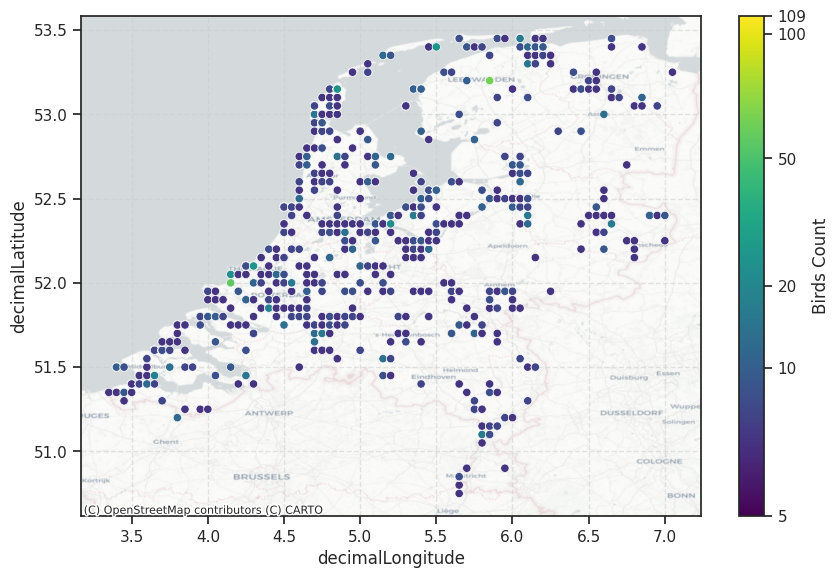

In [107]:
dfX = df[(df['Phalacrocorax carbo'] > 5) & (df['year'] >= 2020) & (df['year'] <= 2025) ]
my_norm = colors.PowerNorm(gamma=0.4, vmin=5, vmax=109)

plt.figure(figsize=(10, 6.5))
# 1. Plot (notice legend=False)
ax = sns.scatterplot(
    data=dfX, x='decimalLongitude', y='decimalLatitude', 
    hue='Phalacrocorax carbo', hue_norm=my_norm, palette='viridis', legend=False
)

cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.CartoDB.Positron)
# 2. Add a colorbar and force your exact numbers onto it
sm = plt.cm.ScalarMappable(cmap='viridis', norm=my_norm)
cbar = plt.colorbar(sm, ax=ax, label='Birds Count')
cbar.set_ticks([5, 10, 20, 50, 100, 109])

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [102]:
dfX.tail

<bound method NDFrame.tail of           decimalLatitude  decimalLongitude  eventDate  total_observations  \
4681                50.75              5.65 2022-10-26                77.0   
56615               50.80              5.65 2021-01-02               305.0   
108862              50.85              5.65 2020-01-19               116.0   
108869              50.85              5.65 2020-01-26               102.0   
108895              50.85              5.65 2020-02-21               451.0   
...                   ...               ...        ...                 ...   
12476867            53.45              6.15 2025-10-20               594.0   
12476868            53.45              6.15 2025-10-21               547.0   
12476900            53.45              6.15 2025-11-22               259.0   
12481954            53.45              6.20 2023-09-24               165.0   
12492989            53.45              6.65 2021-12-10               302.0   

          speciesgroup_observatio

### Average monthly observations of cormorants
Cormorants are migratory. We expect a clear seasonal pattern here - this is usually one of the strongest signals in any bird-sighting dataset.
Explains that they are winter migratory birds. Since the netherlands is not as cold during winter cormorants from northern countries arrive here and
increase the population. Since they prefer cold weather but not too cold it is expected to see a decrease in the population during the summer months.

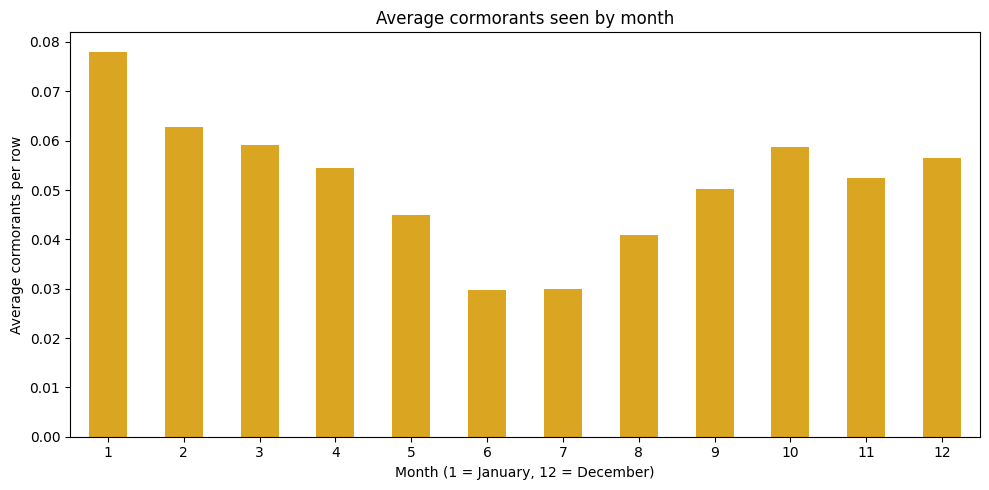

In [71]:
month_means = df.groupby("month")["Phalacrocorax carbo"].mean()

plt.figure(figsize=(10, 5))
month_means.plot(kind="bar", color="goldenrod")
plt.title("Average cormorants seen by month")
plt.xlabel("Month (1 = January, 12 = December)")
plt.ylabel("Average cormorants per row")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Cormorants seen by day of year

Same idea, but at daily resolution. Catches finer migration patterns inside each month.

In [72]:
# doy_means = df.groupby("day_of_year")["Phalacrocorax carbo"].mean()

# plt.figure(figsize=(12, 5))
# doy_means.plot(color="darkgreen", linewidth=1.2)
# plt.title("Average cormorants seen by day")
# plt.xlabel("Day of year")
# plt.ylabel("Average cormorants per row")
# plt.tight_layout()
# plt.show()

### Cormorants seen by year


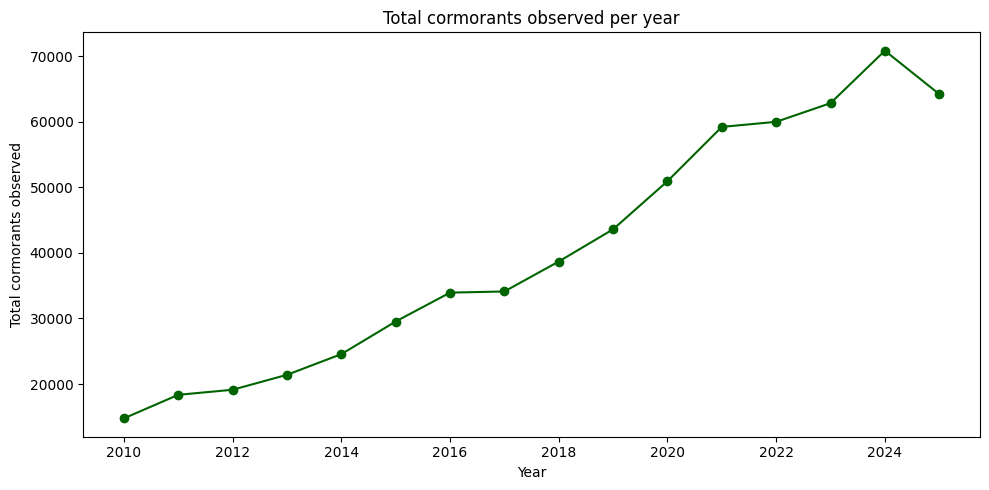

In [73]:
yearly = df.groupby(df["eventDate"].dt.year)["Phalacrocorax carbo"].sum()

plt.figure(figsize=(10, 5))
yearly.plot(kind="line", marker="o", color="darkgreen")
plt.title("Total cormorants observed per year")
plt.xlabel("Year")
plt.ylabel("Total cormorants observed")
plt.tight_layout()
plt.show()

### Cormorants per month over time


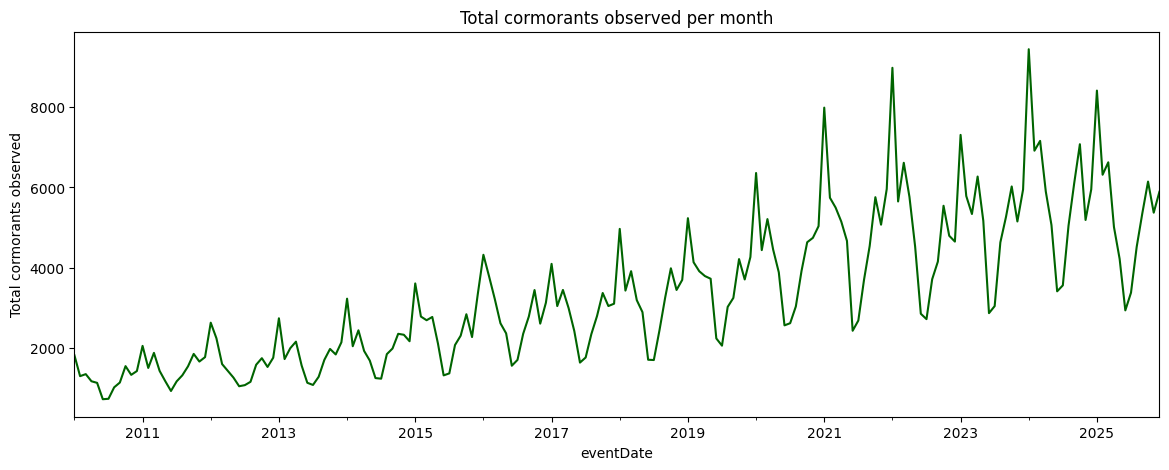

In [74]:
import pandas as pd
import matplotlib.pyplot as plt

df_plot = df
# df_plot = pd.read_parquet("bird_habitats_weather.parquet")

monthly = df_plot.groupby(df_plot["eventDate"].dt.to_period("M"))["Phalacrocorax carbo"].sum()

monthly.plot(figsize=(14, 5), color="darkgreen")
plt.title("Total cormorants observed per month")
plt.ylabel("Total cormorants observed")
plt.show()

### Faceted barchart
This barchart shows per different bins 6-10, 11-20, 21-50, 50+ what the count of observations in the given range is based on main habitat

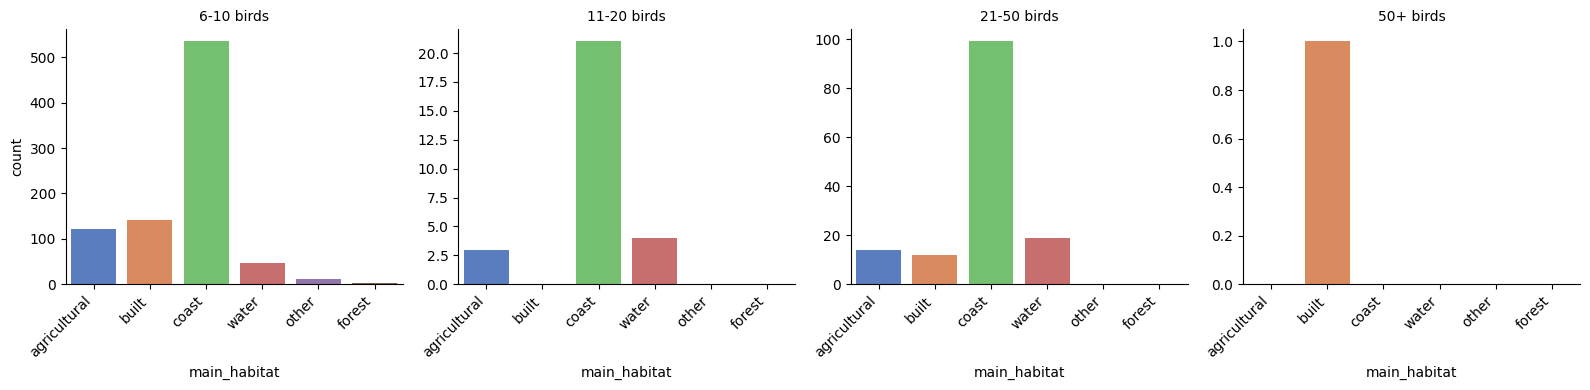

In [75]:
# 1. Filter out wetlands and bucket the counts
df_non_wetland = df[df['wetland'] == 0].copy()
df_non_wetland['bird_brackets'] = pd.cut(
    df_non_wetland['Phalacrocorax carbo'], 
    bins=[5, 10, 20, 50, float('inf')], 
    labels=['6-10 birds', '11-20 birds', '21-50 birds', '50+ birds']
)
df_filtered = df_non_wetland.dropna(subset=['bird_brackets'])

# 2. Use catplot to split into separate subplots side-by-side
g = sns.catplot(
    data=df_filtered,
    x='main_habitat',
    hue='main_habitat',
    col='bird_brackets',    # Creates a separate plot for each bracket
    kind='count',
    sharey=False,           # CRITICAL: Gives each plot its own Y-axis scale!
    palette='muted',
    height=4,
    aspect=1.0
)

# Rotate habitat labels so they don't overlap
g.set_xticklabels(rotation=45, ha='right')
g.set_titles("{col_name}") # Cleans up the subplot titles

plt.tight_layout()
plt.show()

### Log scaled box plot of total observations

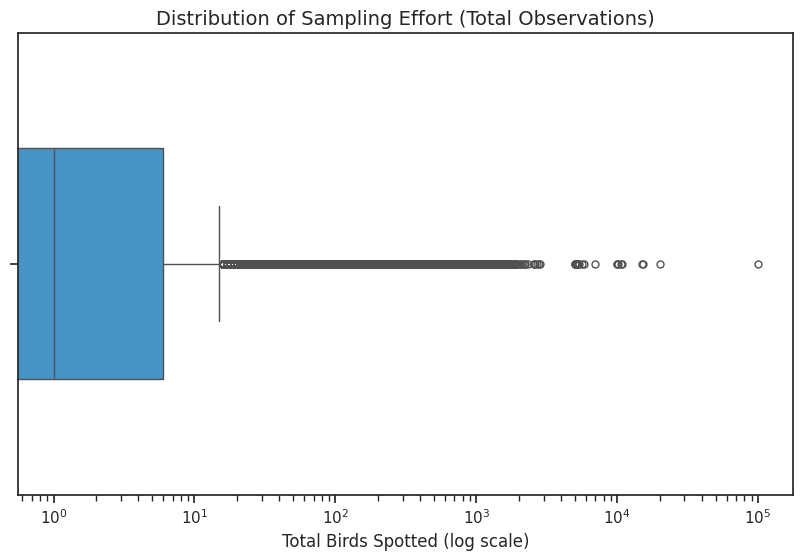

In [76]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="ticks")

ax = sns.boxplot(
    x=df['total_observations'], 
    color='#3498db',
    width=0.5,
    fliersize=5  
)
ax.set_xscale("log")

plt.title('Distribution of Sampling Effort (Total Observations)', fontsize=14)
plt.xlabel('Total Birds Spotted (log scale)', fontsize=12)

plt.show()

### Correlation matrix logic
Here we define our columns and a function that makes the correlation matrices since they are basically repeating code with different parameters

In [77]:

# Split the variables into groups so we get smaller, easier-to-read matrixes
bird_cols    = ["Phalacrocorax carbo", "total_observations", "speciesgroup_observations"]
habitat_cols = ["agricultural", "built", "coast", "forest", "water", "wetland", "sand/heather"]
df["is_raining"] = (df["RH"] > 0).astype(int)
weather_cols = ["TG", "TN", "TX", "RH", "is_raining", "FG", "UG", "SQ", "Q"]

pretty = {
    "TG": "Mean temp",
    "TN": "Min temp",
    "TX": "Max temp",
    "RH": "Rain (mm)",
    "is_raining": "Is Raining",
    "FG": "Wind (m/s)",
    "UG": "Humidity (%)",
    "SQ": "Sunshine (h)",
    "Q":  "Solar radiation",
}

def plot_corr(cols, title, method="pearson"):
    corr = df[cols].corr(method=method).rename(index=pretty, columns=pretty)
    mask = np.triu(np.ones_like(corr, dtype=bool))
    plt.figure(figsize=(9, 7))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                square=True, linewidths=0.3, annot_kws={"size": 8}, mask=mask)
    plt.title(title)
    plt.tight_layout()
    plt.show()

### Bird Sightings to Habitats Pearson correlation matrix 

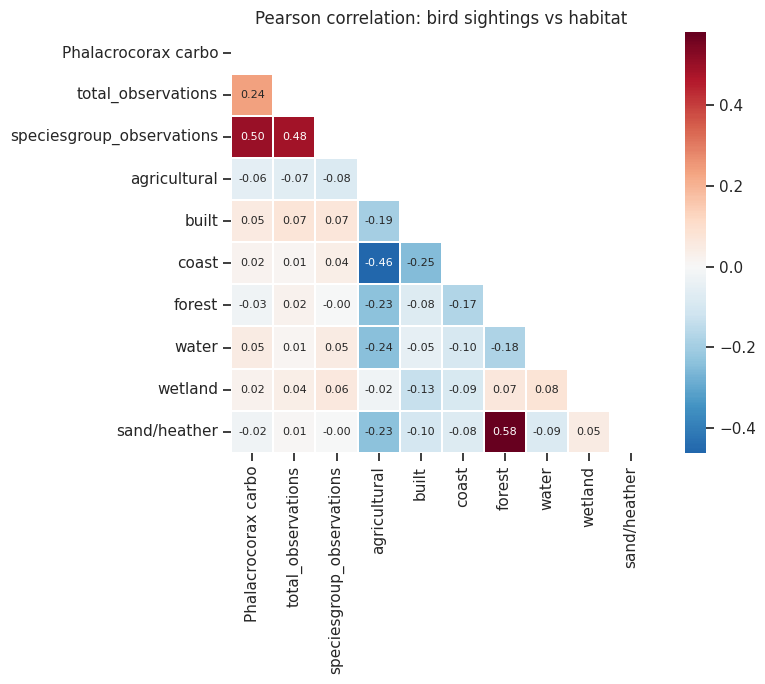

In [78]:
plot_corr(bird_cols + habitat_cols, "Pearson correlation: bird sightings vs habitat")

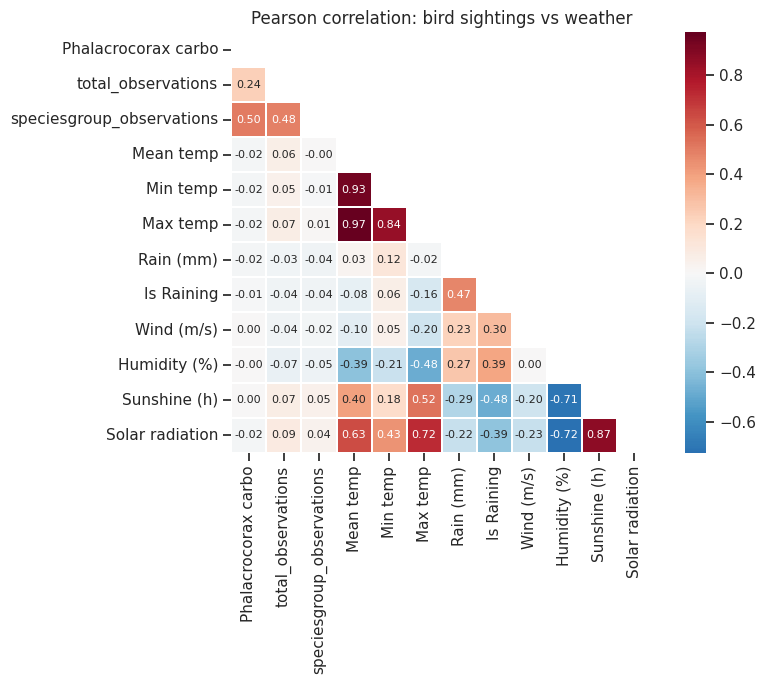

In [79]:

plot_corr(bird_cols + weather_cols, "Pearson correlation: bird sightings vs weather")

### Bird Sightings to Habitat Spearman correlation matrix

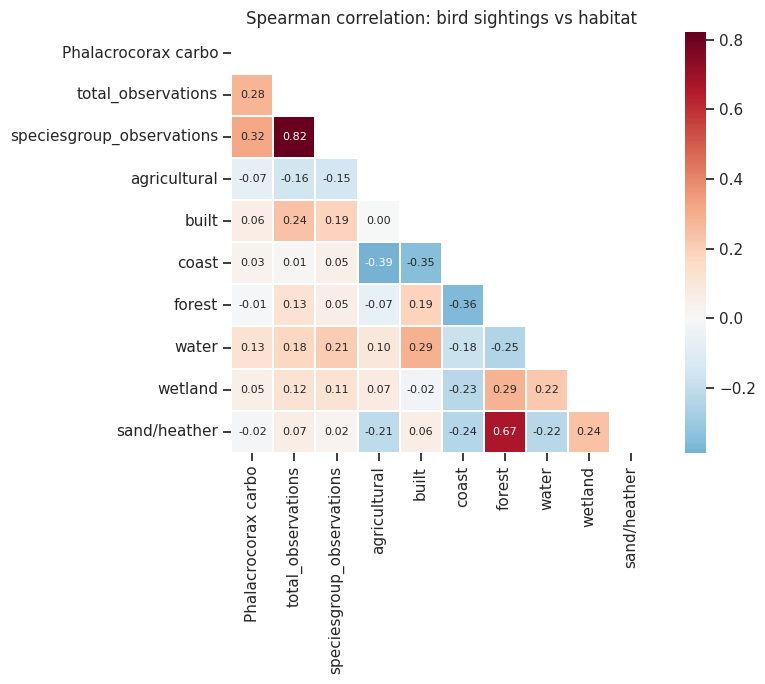

In [80]:

plot_corr(bird_cols + habitat_cols, "Spearman correlation: bird sightings vs habitat", "spearman")

### Bird Sightings to Weather Spearman correlation matrix

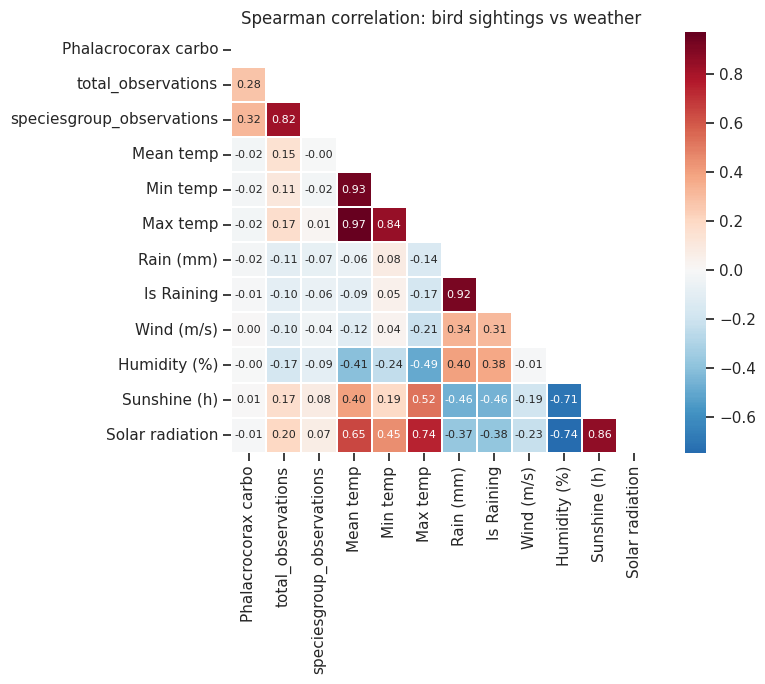

In [81]:

plot_corr(bird_cols + weather_cols, "Spearman correlation: bird sightings vs weather", "spearman")

### Cormorants correlation with Rain


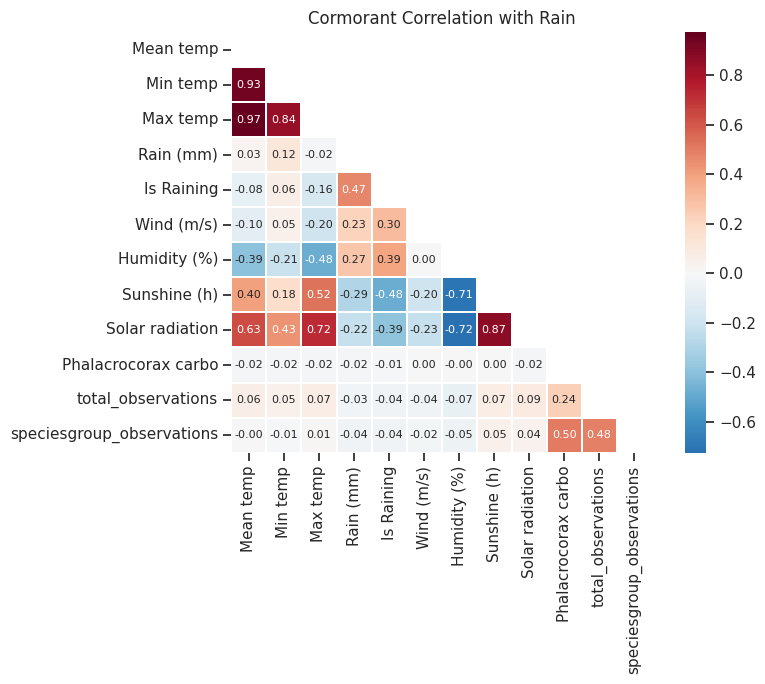

In [84]:

plot_corr(weather_cols + bird_cols, "Cormorant Correlation with Rain")

### Cormorants seen vs temperature

We split the daily mean temperature (TG) into 2 °C ranges and plot the average number of cormorants seen per row in each range.

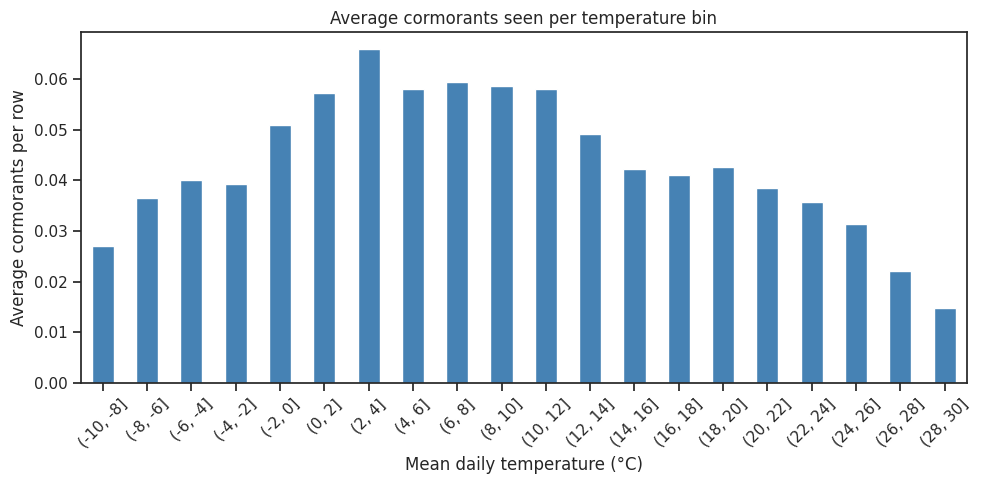

In [85]:
plot_df = df[["TG", "Phalacrocorax carbo"]].dropna().copy()
plot_df["TG_bin"] = pd.cut(plot_df["TG"], bins=range(-10, 32, 2))
temp_means = plot_df.groupby("TG_bin", observed=True)["Phalacrocorax carbo"].mean()

plt.figure(figsize=(10, 5))
temp_means.plot(kind="bar", color="steelblue")
plt.title("Average cormorants seen per temperature bin")
plt.xlabel("Mean daily temperature (°C)")
plt.ylabel("Average cormorants per row")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Cormorants seen vs humidity

Same idea, but binned by daily mean humidity 

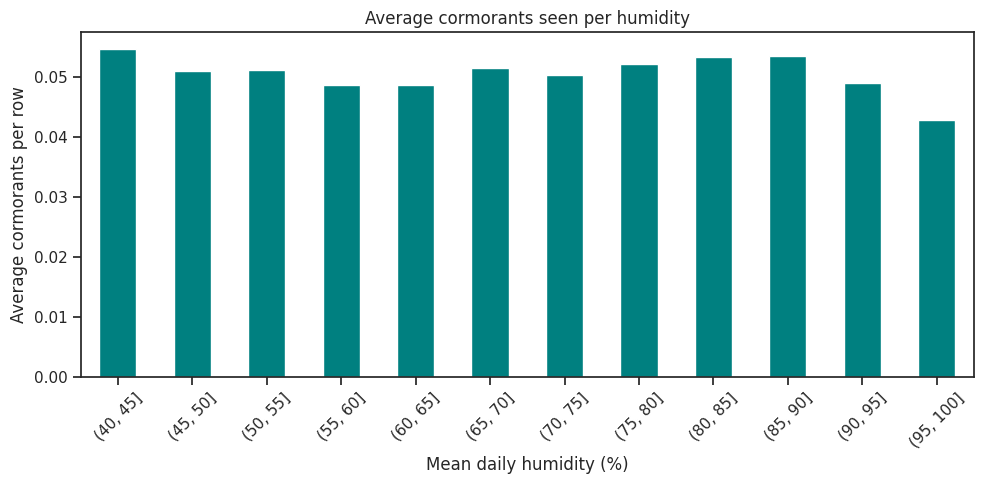

In [86]:
plot_df = df[["UG", "Phalacrocorax carbo"]].dropna().copy()
plot_df["UG_bin"] = pd.cut(plot_df["UG"], bins=range(40, 101, 5))
hum_means = plot_df.groupby("UG_bin", observed=True)["Phalacrocorax carbo"].mean()

plt.figure(figsize=(10, 5))
hum_means.plot(kind="bar", color="teal")
plt.title("Average cormorants seen per humidity")
plt.xlabel("Mean daily humidity (%)")
plt.ylabel("Average cormorants per row")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Cormorants seen vs rain

Group days into 4 buckets - none / light / moderate / heavy - and check average sightings per bucket.

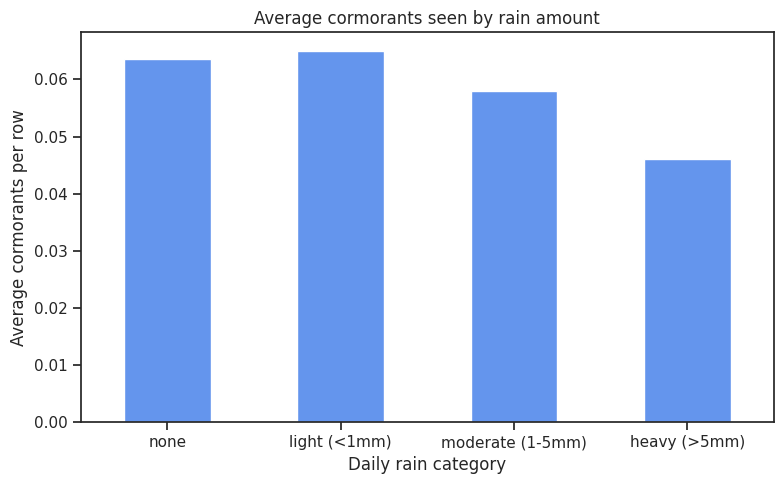

In [ ]:
plot_df = df[["RH", "Phalacrocorax carbo"]].dropna().copy()
plot_df["rain_cat"] = pd.cut(
    plot_df["RH"],
    bins=[-0.1, 0, 1, 5, 1000],
    labels=["none", "light (<1mm)", "moderate (1-5mm)", "heavy (>5mm)"],
)
rain_means = plot_df.groupby("rain_cat", observed=True)["Phalacrocorax carbo"].mean()

plt.figure(figsize=(8, 5))
rain_means.plot(kind="bar", color="cornflowerblue")
plt.title("Average cormorants seen by rain amount")
plt.xlabel("Daily rain category")
plt.ylabel("Average cormorants per row")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Cormorants seen vs wind

Binned by daily mean wind speed (`FG`, in m/s).

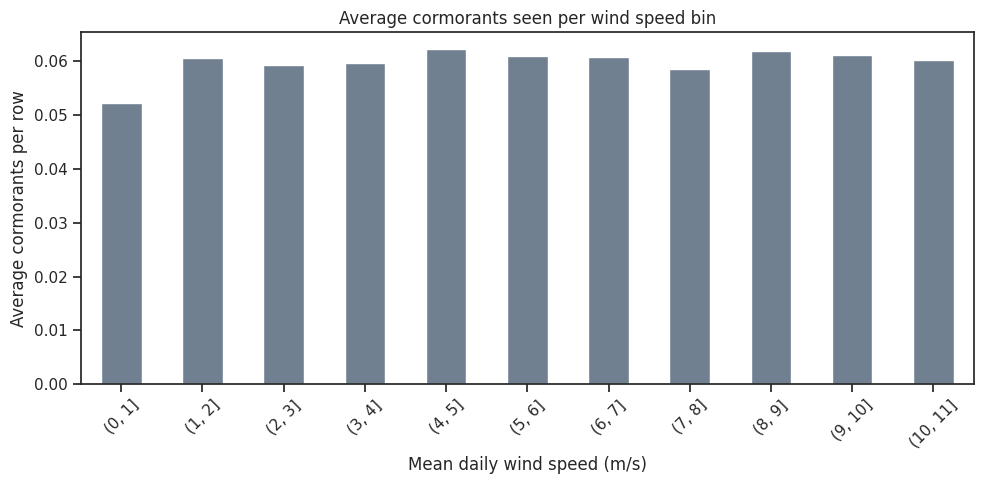

In [ ]:
plot_df = df[["FG", "Phalacrocorax carbo"]].dropna().copy()
plot_df["FG_bin"] = pd.cut(plot_df["FG"], bins=np.arange(0, 12, 1))
wind_means = plot_df.groupby("FG_bin", observed=True)["Phalacrocorax carbo"].mean()

plt.figure(figsize=(10, 5))
wind_means.plot(kind="bar", color="slategray")
plt.title("Average cormorants seen per wind speed bin")
plt.xlabel("Mean daily wind speed (m/s)")
plt.ylabel("Average cormorants per row")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Modelling

In [87]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import RandomizedSearchCV
from sklearn.cluster import KMeans

### Sampling

In [ ]:
df.head()

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Phalacrocorax carbo,agricultural,built,coast,forest,...,TG,TN,TX,RH,FG,UG,SQ,Q,year,week
0,50.75,5.65,2010-01-01,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,-2.0,-6.1,-1.1,0.1,4.6,91.0,0.0,33.0,2010,53
1,50.75,5.65,2010-01-02,25.0,25,1,1.7747,0.0568,0.0,0.0616,...,-2.1,-6.7,0.2,0.2,4.9,90.0,2.7,260.0,2010,53
2,50.75,5.65,2010-01-03,3.0,3,0,1.7747,0.0568,0.0,0.0616,...,-3.9,-6.7,0.8,3.0,3.3,92.0,0.3,178.0,2010,53
3,50.75,5.65,2010-01-04,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,-5.4,-10.5,-3.0,0.4,3.3,89.0,0.4,218.0,2010,1
4,50.75,5.65,2010-01-05,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,-2.3,-4.6,-1.0,0.4,3.5,92.0,0.0,177.0,2010,1


In [ ]:
df.describe()

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Phalacrocorax carbo,agricultural,built,coast,forest,...,TG,TN,TX,RH,FG,UG,SQ,Q,year,week
count,1.255876e+07,1.255876e+07,12558756,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07,...,1.253764e+07,1.253764e+07,1.253764e+07,1.253764e+07,1.253608e+07,1.253764e+07,1.253630e+07,1.253630e+07,1.255876e+07,12558756.0
mean,5.223006e+01,5.532783e+00,2017-12-31 11:59:59.999999,8.067763e+00,4.330658e+00,5.143431e-02,9.452277e+00,2.404833e+00,1.302932e+00,1.621184e+00,...,1.088453e+01,6.726166e+00,1.481465e+01,2.228206e+00,4.141858e+00,8.026855e+01,5.079891e+00,1.067049e+03,2.017500e+03,26.563997
min,5.075000e+01,3.350000e+00,2010-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,-1.270000e+01,-1.950000e+01,-6.700000e+00,0.000000e+00,0.000000e+00,2.900000e+01,0.000000e+00,2.000000e+01,2.010000e+03,1.0
25%,5.170000e+01,4.900000e+00,2013-12-31 18:00:00,0.000000e+00,0.000000e+00,0.000000e+00,5.348400e+00,7.667000e-01,0.000000e+00,1.494000e-01,...,6.400000e+00,2.600000e+00,9.300000e+00,0.000000e+00,2.600000e+00,7.400000e+01,1.200000e+00,3.340000e+02,2.013750e+03,14.0
50%,5.220000e+01,5.650000e+00,2017-12-31 12:00:00,1.000000e+00,0.000000e+00,0.000000e+00,1.056820e+01,1.559900e+00,0.000000e+00,7.092000e-01,...,1.080000e+01,6.900000e+00,1.470000e+01,1.000000e-01,3.700000e+00,8.200000e+01,4.400000e+00,9.030000e+02,2.017500e+03,27.0
75%,5.280000e+01,6.200000e+00,2021-12-31 06:00:00,6.000000e+00,2.000000e+00,0.000000e+00,1.380080e+01,3.291600e+00,0.000000e+00,2.036400e+00,...,1.580000e+01,1.120000e+01,2.030000e+01,2.400000e+00,5.200000e+00,8.800000e+01,8.200000e+00,1.674000e+03,2.021250e+03,40.0
max,5.350000e+01,7.200000e+00,2025-12-31 00:00:00,1.000400e+05,2.779000e+03,1.090000e+02,1.810460e+01,1.435380e+01,1.934870e+01,1.699850e+01,...,3.090000e+01,2.350000e+01,4.020000e+01,1.064000e+02,1.800000e+01,1.000000e+02,1.570000e+01,3.130000e+03,2.025000e+03,53.0
std,6.605211e-01,8.748856e-01,NaN,3.912502e+01,1.606794e+01,3.364980e-01,5.147907e+00,2.419758e+00,3.970215e+00,2.385737e+00,...,6.218839e+00,5.777645e+00,7.255706e+00,4.617264e+00,2.101596e+00,1.033570e+01,4.252923e+00,8.067607e+02,4.609698e+00,15.061596


### Filtering the data based on date

In [88]:
df_filtered = df[df['eventDate'].dt.year > 2019]

In [ ]:
df_filtered.head(5)

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Phalacrocorax carbo,agricultural,built,coast,forest,...,TN,TX,RH,FG,UG,SQ,Q,year,week,is_raining
3652,50.75,5.65,2020-01-01,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,-3.2,2.9,0.0,1.9,99.0,2.7,318.0,2020,1,0
3653,50.75,5.65,2020-01-02,2.0,2,0,1.7747,0.0568,0.0,0.0616,...,-0.6,7.4,0.0,4.5,89.0,1.3,178.0,2020,1,0
3654,50.75,5.65,2020-01-03,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,3.5,9.4,4.9,5.8,92.0,0.0,71.0,2020,1,1
3655,50.75,5.65,2020-01-04,10.0,9,1,1.7747,0.0568,0.0,0.0616,...,2.5,6.9,0.1,3.6,90.0,1.9,237.0,2020,1,1
3656,50.75,5.65,2020-01-05,0.0,0,0,1.7747,0.0568,0.0,0.0616,...,5.2,7.0,0.0,3.0,84.0,0.0,116.0,2020,1,0


In [ ]:
df_filtered.dtypes

decimalLatitude                     float64
decimalLongitude                    float64
eventDate                    datetime64[us]
total_observations                  float64
speciesgroup_observations             int64
Phalacrocorax carbo                   int64
agricultural                        float64
built                               float64
coast                               float64
forest                              float64
other                               float64
sand/heather                        float64
water                               float64
wetland                             float64
main_habitat                            str
month                                 int32
STN                                   int64
TG                                  float64
TN                                  float64
TX                                  float64
RH                                  float64
FG                                  float64
UG                              

In [ ]:
df_filtered.tail(5)

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Phalacrocorax carbo,agricultural,built,coast,forest,...,TG,TN,TX,RH,FG,UG,SQ,Q,year,week
12558751,53.5,6.55,2025-12-27,0.0,0,0,0.0353,0.0,18.4195,0.0,...,3.4,-2.4,7.2,0.0,2.2,90.0,0.5,126.0,2025,52
12558752,53.5,6.55,2025-12-28,0.0,0,0,0.0353,0.0,18.4195,0.0,...,0.3,-3.2,4.4,0.0,1.4,97.0,1.7,198.0,2025,52
12558753,53.5,6.55,2025-12-29,0.0,0,0,0.0353,0.0,18.4195,0.0,...,5.2,1.1,7.4,0.2,3.3,83.0,0.5,141.0,2025,1
12558754,53.5,6.55,2025-12-30,0.0,0,0,0.0353,0.0,18.4195,0.0,...,3.2,-2.1,6.4,0.1,3.0,70.0,5.1,295.0,2025,1
12558755,53.5,6.55,2025-12-31,0.0,0,0,0.0353,0.0,18.4195,0.0,...,4.0,-1.1,7.4,0.1,5.2,89.0,1.7,195.0,2025,1


### KMeans Clustering


Using the elbow method we determine the optimal cluster count when the cormorant was present. The optimal cluster count came to be 4.


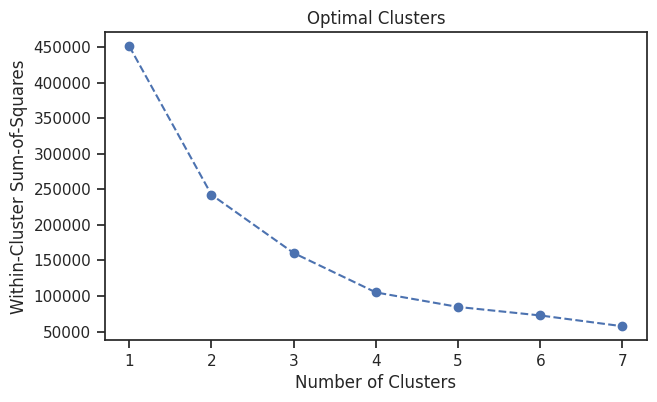

In [127]:
df_clusters = df[df["Phalacrocorax carbo"] > 0].copy()
X_clusters = df_clusters[["decimalLongitude", "decimalLatitude"]].values

inertia = []
K_range = range(1, 8)

for k in K_range:
    kmeans = KMeans(
        n_clusters = k,
        random_state=42,
        n_init="auto"
    ).fit(X_clusters)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_range, inertia, marker="o", linestyle="--", color="b")
plt.xlabel("Number of Clusters")
plt.ylabel("Within-Cluster Sum-of-Squares")
plt.title("Optimal Clusters")
plt.grid(False)
plt.show()

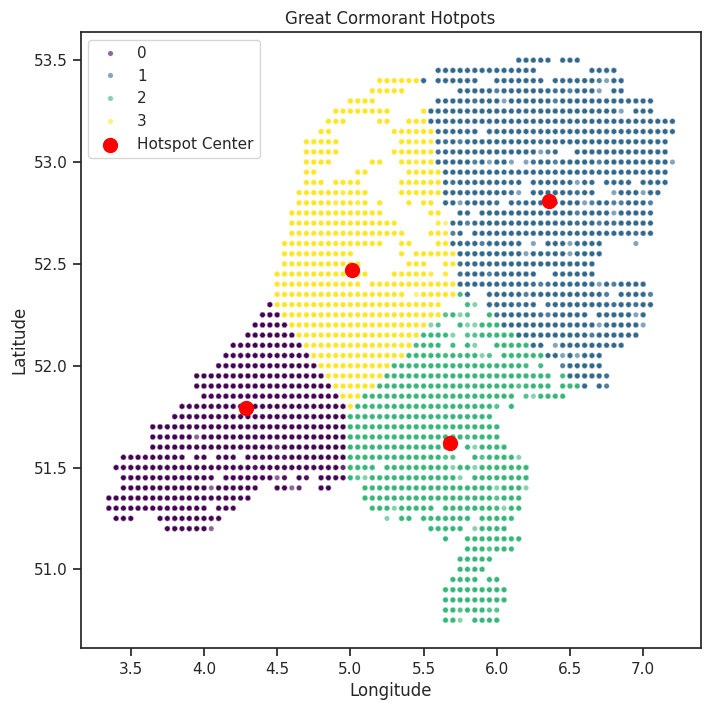

In [140]:
from matplotlib.collections import LineCollection

dfX = df[(df["Phalacrocorax carbo"] > 5)].copy()
X_heatmap_sightings = dfX[["decimalLongitude", "decimalLatitude"]].values

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init="auto"
).fit(X_clusters)

df_clusters["hotspot_cluster"] = kmeans.labels_
centers = kmeans.cluster_centers_

plt.figure(figsize=(8, 8))
sns.scatterplot(
    data=df_clusters, 
    x="decimalLongitude", 
    y="decimalLatitude", 
    hue="hotspot_cluster", 
    palette="viridis", 
    alpha=0.6,
    s=15
)

plt.scatter(
    centers[:, 0], centers[:, 1], 
    c="red", s=100, marker="o", label="Hotspot Center"
)

plt.title("Great Cormorant Hotpots")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(False)
plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


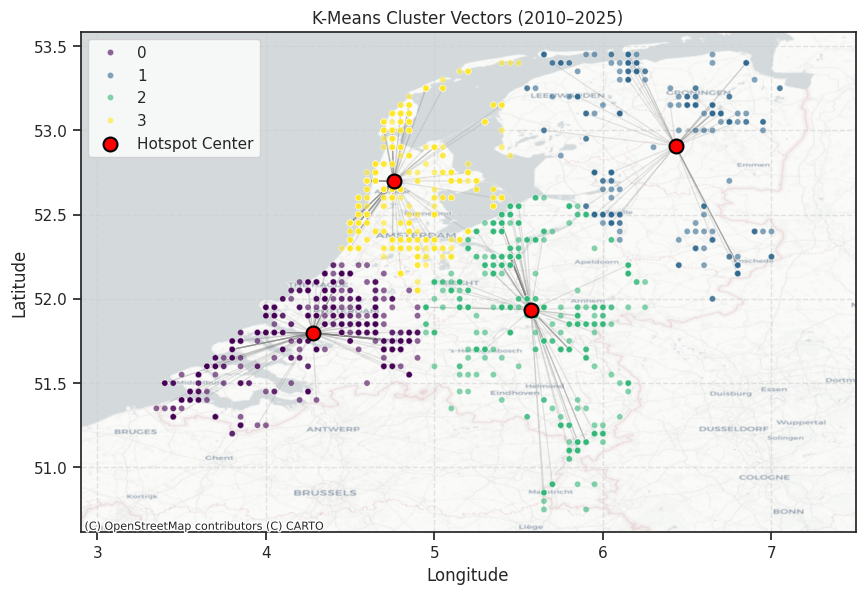

In [141]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init="auto")
dfX["hotspot_cluster"] = kmeans.fit_predict(X_heatmap_sightings)
centers = kmeans.cluster_centers_

fig, ax = plt.subplots(figsize=(10, 6.5))

sns.scatterplot(
    data=dfX,
    x="decimalLongitude",
    y="decimalLatitude",
    hue="hotspot_cluster",
    palette="viridis",
    alpha=0.6,
    s=20,
    zorder=2,
    ax=ax,
)

labels = dfX["hotspot_cluster"].values
for i in range(0, len(X_heatmap_sightings), 15):
    cluster_idx = labels[i]
    center_x, center_y = centers[cluster_idx, 0], centers[cluster_idx, 1]
    point_x, point_y = X_heatmap_sightings[i, 0], X_heatmap_sightings[i, 1]
    ax.plot(
        [point_x, center_x],
        [point_y, center_y],
        color="grey",
        alpha=0.2,
        linewidth=0.9,
        zorder=1,
    )

ax.scatter(
    centers[:, 0],
    centers[:, 1],
    c="red",
    s=100,
    marker="o",
    label="Hotspot Center",
    edgecolor="black",
    linewidth=1.5,
    zorder=3,
)

cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.CartoDB.Positron)

ax.set_aspect("equal", adjustable="datalim")
plt.title("K-Means Cluster Vectors (2010–2025)")
plt.xlabel("Longitude")

plt.ylabel("Latitude")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

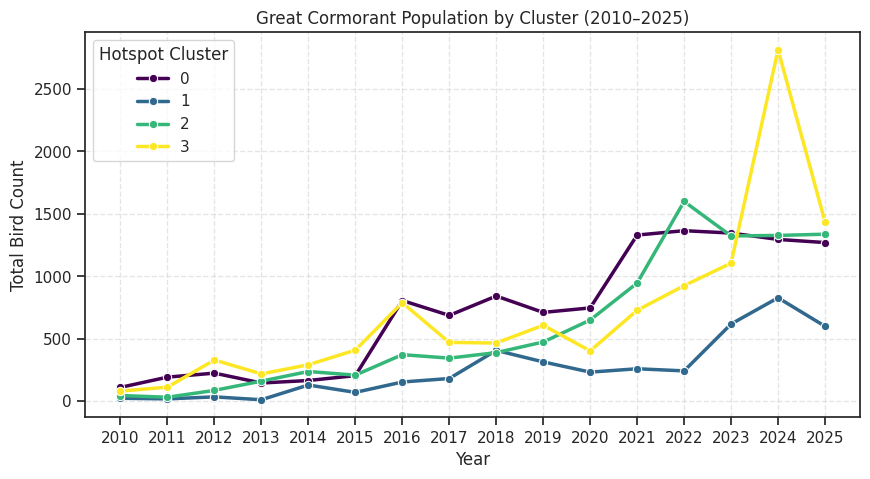

In [142]:



df_timeline = (
    dfX.groupby(["year", "hotspot_cluster"])["Phalacrocorax carbo"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=df_timeline,
    x="year",
    y="Phalacrocorax carbo",
    hue="hotspot_cluster",
    palette="viridis",
    marker="o",
    linewidth=2.5,
)

plt.title("Great Cormorant Population by Cluster (2010–2025)")
plt.xlabel("Year")
plt.ylabel("Total Bird Count")
plt.xticks(range(2010, 2026))
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Hotspot Cluster")
plt.show()

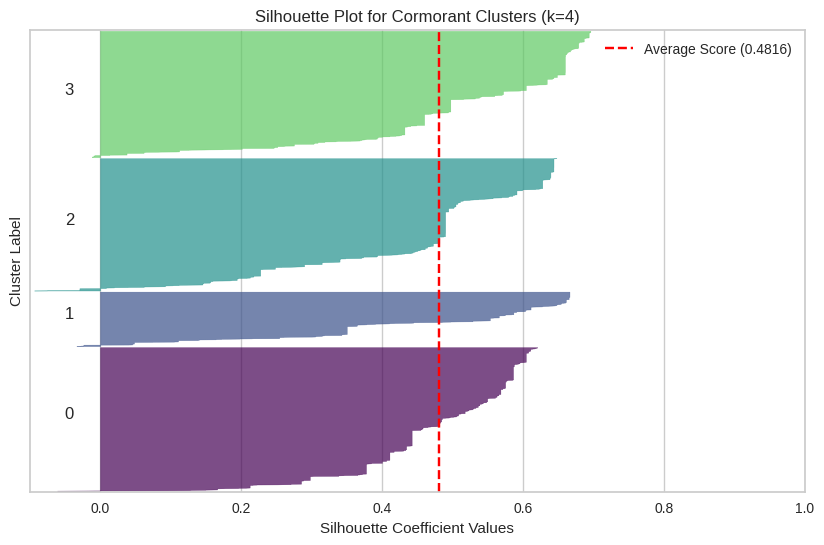

In [150]:
from sklearn.metrics import silhouette_samples, silhouette_score

kmeans = KMeans(n_clusters=4, random_state=42, n_init="auto")
cluster_labels = kmeans.fit_predict(X_heatmap_sightings)
avg_score = silhouette_score(X_heatmap_sightings, cluster_labels)
sample_silhouette_values = silhouette_samples(
    X_heatmap_sightings, cluster_labels
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim([-0.1, 1.0])
ax.set_ylim([0, len(X_heatmap_sightings) + (4 + 1) * 10])

y_lower = 10
for i in range(4):
    ith_cluster_silhouette_values = sample_silhouette_values[
        cluster_labels == i
    ]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.viridis(float(i) / 4)
    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette_values,
        facecolor=color,
        edgecolor=color,
        alpha=0.7,
    )

    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

ax.set_title("Silhouette Plot for Cormorant Clusters (k=4)")
ax.set_xlabel("Silhouette Coefficient Values")
ax.set_ylabel("Cluster Label")

ax.axvline(
    x=avg_score,
    color="red",
    linestyle="--",
    label=f"Average Score ({avg_score:.4f})",
)
ax.set_yticks([])
ax.legend()
plt.show()

### Creating the seen column

In [ ]:
# df_filtered['sasho'] = pd.to_numeric(pd.to_datetime(df_filtered['eventDate']))
# df_filtered['sasho1'] = pd.to_numeric(pd.to_datetime(df_filtered['date']))

In [ ]:
df_filtered['seen'] = (df_filtered['Phalacrocorax carbo'] > 0).astype(int)

### Splitting the data

In [ ]:
X = df_filtered.drop(columns=['Phalacrocorax carbo','seen'])
y = df_filtered['seen']

train_mask = df_filtered['eventDate'].dt.year <= 2023      # train 2020-2023
X_train, X_test = X[train_mask], X[~train_mask]            # test  2024-2025
y_train, y_test = y[train_mask], y[~train_mask]

In [ ]:
X_train.head(5)

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,agricultural,built,coast,forest,other,...,TX,RH,FG,UG,SQ,Q,year,week,month_num,month_name
3652,50.75,5.65,2020-01-01,0.0,0,1.7747,0.0568,0.0,0.0616,0.0582,...,2.9,0.0,1.9,99.0,2.7,318.0,2020,1,1,January
3653,50.75,5.65,2020-01-02,2.0,2,1.7747,0.0568,0.0,0.0616,0.0582,...,7.4,0.0,4.5,89.0,1.3,178.0,2020,1,1,January
3654,50.75,5.65,2020-01-03,0.0,0,1.7747,0.0568,0.0,0.0616,0.0582,...,9.4,4.9,5.8,92.0,0.0,71.0,2020,1,1,January
3655,50.75,5.65,2020-01-04,10.0,9,1.7747,0.0568,0.0,0.0616,0.0582,...,6.9,0.1,3.6,90.0,1.9,237.0,2020,1,1,January
3656,50.75,5.65,2020-01-05,0.0,0,1.7747,0.0568,0.0,0.0616,0.0582,...,7.0,0.0,3.0,84.0,0.0,116.0,2020,1,1,January


In [ ]:
X_train.dtypes

decimalLatitude                     float64
decimalLongitude                    float64
eventDate                    datetime64[us]
total_observations                  float64
speciesgroup_observations             int64
agricultural                        float64
built                               float64
coast                               float64
forest                              float64
other                               float64
sand/heather                        float64
water                               float64
wetland                             float64
main_habitat                            str
month                                 int32
day_of_year                           int32
STN                                   int64
TG                                  float64
TN                                  float64
TX                                  float64
RH                                  float64
FG                                  float64
UG                              

In [ ]:
y_train.head(5)

3652    0
3653    0
3654    0
3655    1
3656    0
Name: seen, dtype: int64

### Baseline model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Tuned hyperparameters settings

baseModel = RandomForestClassifier(
    n_estimators=150,
    min_samples_split=2,
    min_samples_leaf=50,
    max_features="log2",
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Feature-leak fix: drop speciesgroup_observations
drop_cols = ['eventDate', 'main_habitat', 'month_name', 'speciesgroup_observations']
X_train_numeric = X_train.drop(columns=drop_cols, errors='ignore')
X_test_numeric = X_test.drop(columns=drop_cols, errors='ignore')

baseModel.fit(X_train_numeric, y_train)
print(baseModel.predict(X_test_numeric))

[0 1 0 ... 0 0 0]


In [ ]:
import sklearn.metrics as skm
from sklearn.metrics import roc_curve, auc

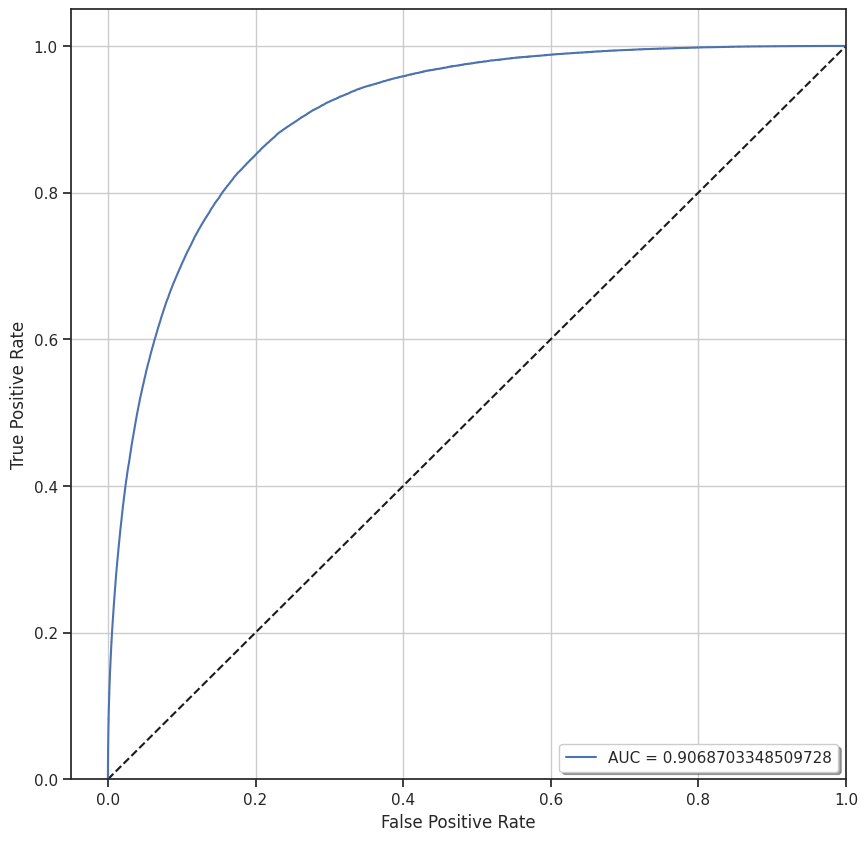

In [ ]:
acc = baseModel.score(X_test_numeric,y_test)

Y_score = baseModel.predict_proba(X_test_numeric)[:,1]
fpr = dict()
tpr = dict()
fpr, tpr, sasho  = roc_curve(y_test, Y_score)

roc_auc = dict()
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10,10))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([-0.05, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(True)
plt.plot(fpr, tpr, label='AUC = {0}'.format(roc_auc))
plt.legend(loc="lower right", shadow=True, fancybox =True) 
plt.show()

In [ ]:
print(acc)

0.8470098029153984


In [ ]:
y_pred = baseModel.predict(X_test_numeric)

report = classification_report(y_test, y_pred)

In [ ]:
print(report)

              precision    recall  f1-score   support

           0       0.98      0.85      0.91    773871
           1       0.27      0.79      0.40     54352

    accuracy                           0.85    828223
   macro avg       0.63      0.82      0.66    828223
weighted avg       0.94      0.85      0.88    828223



crazy burger model

In [ ]:
def burger_model(row): 
    return 0

In [ ]:
df_eval = df_filtered.copy()
df_eval['predicted_seen'] = df_eval.apply(lambda row: burger_model(row), axis=1)

y_true = df_filtered["seen"]
y_pred = df_eval["predicted_seen"]

In [ ]:
report = classification_report(y_true, y_pred)

/home/Sasho/HZYear2/Python/cormorant/the-greatest-cormorant/cormorant/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/Sasho/HZYear2/Python/cormorant/the-greatest-cormorant/cormorant/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/Sasho/HZYear2/Python/cormorant/the-greatest-cormorant/cormorant/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted sa

In [ ]:
print(report)

              precision    recall  f1-score   support

           0       0.99      0.78      0.87    773871
           1       0.21      0.84      0.34     54352

    accuracy                           0.78    828223
   macro avg       0.60      0.81      0.60    828223
weighted avg       0.93      0.78      0.83    828223



### Gradient Boosting model

In [ ]:
X_train.head(5)

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,agricultural,built,coast,forest,other,...,TX,RH,FG,UG,SQ,Q,year,week,month_num,month_name
3652,50.75,5.65,2020-01-01,0.0,0,1.7747,0.0568,0.0,0.0616,0.0582,...,2.9,0.0,1.9,99.0,2.7,318.0,2020,1,1,January
3653,50.75,5.65,2020-01-02,2.0,2,1.7747,0.0568,0.0,0.0616,0.0582,...,7.4,0.0,4.5,89.0,1.3,178.0,2020,1,1,January
3654,50.75,5.65,2020-01-03,0.0,0,1.7747,0.0568,0.0,0.0616,0.0582,...,9.4,4.9,5.8,92.0,0.0,71.0,2020,1,1,January
3655,50.75,5.65,2020-01-04,10.0,9,1.7747,0.0568,0.0,0.0616,0.0582,...,6.9,0.1,3.6,90.0,1.9,237.0,2020,1,1,January
3656,50.75,5.65,2020-01-05,0.0,0,1.7747,0.0568,0.0,0.0616,0.0582,...,7.0,0.0,3.0,84.0,0.0,116.0,2020,1,1,January


In [ ]:
X_train_numeric.dtypes

decimalLatitude       float64
decimalLongitude      float64
total_observations    float64
agricultural          float64
built                 float64
coast                 float64
forest                float64
other                 float64
sand/heather          float64
water                 float64
wetland               float64
month                   int32
day_of_year             int32
STN                     int64
TG                    float64
TN                    float64
TX                    float64
RH                    float64
FG                    float64
UG                    float64
SQ                    float64
Q                     float64
year                    int32
week                   UInt32
month_num               int32
dtype: object

In [ ]:
y_train.head(5)

3652    0
3653    0
3654    0
3655    1
3656    0
Name: seen, dtype: int64

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV

hist = HistGradientBoostingClassifier(
    class_weight="balanced", 
    random_state=42, 
    early_stopping=True,
    validation_fraction=0.1
)

param_dist = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_iter': [100, 200, 300],
    'max_leaf_nodes': [31, 60],
    'l2_regularization': [0.0, 0.1, 1.0]
}

search = RandomizedSearchCV(
    hist, 
    param_dist, 
    n_iter=5,
    cv=2,
    scoring='f1', 
    n_jobs=2
)

X_train_numeric = X_train.drop(columns=drop_cols, errors='ignore') # Still using it to ignore the 'DatetimeArray to dtype float64' eror

search.fit(X_train_numeric, y_train)

print(f"Best parameters: {search.best_params_}")
best_model = search.best_estimator_

Best parameters: {'max_leaf_nodes': 31, 'max_iter': 100, 'learning_rate': 0.01, 'l2_regularization': 0.1}


In [ ]:
histGradientModel = HistGradientBoostingClassifier(
    max_leaf_nodes=31,
    max_iter=100,
    learning_rate=0.01,
    l2_regularization=0.0,
    class_weight="balanced",
    random_state=42
)

X_train_numeric = X_train.drop(columns=drop_cols, errors='ignore')
X_test_numeric = X_test.drop(columns=drop_cols, errors='ignore')


histGradientModel.fit(X_train_numeric, y_train)

print(histGradientModel.predict(X_test_numeric)) 

[0 1 0 ... 0 1 0]


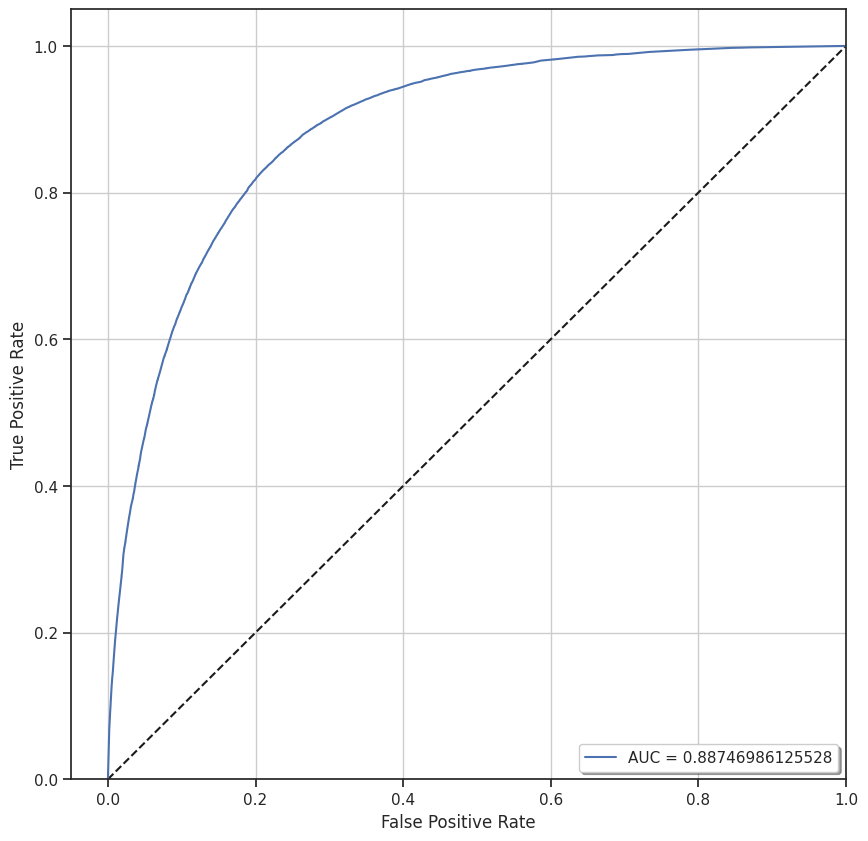

In [ ]:
acc = histGradientModel.score(X_test_numeric,y_test)

Y_score = histGradientModel.predict_proba(X_test_numeric)[:,1]
fpr = dict()
tpr = dict()
fpr, tpr, sasho  = roc_curve(y_test, Y_score)

roc_auc = dict()
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10,10))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([-0.05, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(True)
plt.plot(fpr, tpr, label='AUC = {0}'.format(roc_auc))
plt.legend(loc="lower right", shadow=True, fancybox =True) 
plt.show()

In [ ]:
print(acc)

0.7820828448376826


In [ ]:
y_pred = histGradientModel.predict(X_test_numeric)

report = classification_report(y_test, y_pred)

In [ ]:
print(report)

              precision    recall  f1-score   support

           0       0.99      0.78      0.87    773871
           1       0.21      0.84      0.34     54352

    accuracy                           0.78    828223
   macro avg       0.60      0.81      0.60    828223
weighted avg       0.93      0.78      0.83    828223



### Ramdom Forest outputs

             precision    recall  f1-score   support

           0       0.98      0.85      0.91    773871
           1       0.27      0.79      0.40     54352

    accuracy                           0.85    828223
   macro avg       0.63      0.82      0.66    828223
weighted avg       0.94      0.85      0.88    828223